In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl

mpl.rcParams['svg.fonttype'] = 'none'
mpl.rcParams['font.family'] = 'Arial'
sns.set_style("ticks")

In [3]:
import pickle as pkl

cluster_edges_path = '../cluster_edges/dyngen.pkl' # remember to change this
with open(cluster_edges_path, 'rb') as f:
    cluster_edges = pkl.load(f)
cluster_edges

[('sA->sB', 'sB->sBmid'),
 ('sB->sBmid', 'sBmid->sD'),
 ('sB->sBmid', 'sBmid->sC'),
 ('sBmid->sD', 'sD->sEndD'),
 ('sBmid->sC', 'sC->sEndC')]

In [4]:
data_pair = ('simulate/batch', 'simulate/batch_scgen_cat')
basis = 'umap'
metric_name = 'cbdir'
models = ['scvelo', 'velovi', 'unitvelo', 'velovae', 'deepvelo_cui', 'stt']
results = {}
for cluster_edge in cluster_edges: 
    edge = f'{cluster_edge[0]} -> {cluster_edge[1]}'
    result = {}
    for model in models:
        model_name = model if model != 'scvelo' else 'scvelo_dynamical'
        metrics = {}
        for data in data_pair:
            metric_file = f'../logs/{model}/{data}/{metric_name}_{basis}_{model_name}_velocity.pkl'
            with open(metric_file, 'rb') as f:
                metric = pkl.load(f)
            if edge in metric.keys():
                metrics[data] = metric[edge]
        result[model] = metrics
        if model == 'stt':
            stt_metrics = {}
            for data in data_pair:
                stt_metric_file = f'../logs/{model}/{data}/{metric_name}_{basis}_vj.pkl'
                with open(stt_metric_file, 'rb') as f:
                    stt_metric = pkl.load(f)
                if edge in stt_metric.keys():
                    stt_metrics[data] = stt_metric[edge]
            result['stt(vj)'] = stt_metrics
    results[edge] = result
results

{'sA->sB -> sB->sBmid': {'scvelo': {'simulate/batch': [-0.9611197660017664,
    -0.3914259611802342,
    -0.9999995327302337,
    -0.9970119278345074,
    -0.9993837915336357,
    -0.5725242650520893,
    -0.6961705330616209,
    -0.6403772947917232,
    -0.9963957449399408,
    -0.6060658912735429,
    0.8036615857617446,
    0.006789287270333361,
    -0.928029361335321,
    0.25630340503106785,
    -0.9974677605627464,
    -0.0034636185023822876,
    -0.9435709520961542,
    -0.8977087602815507,
    -0.33650530017643054,
    -0.39911202090134706,
    0.2360176521724912,
    0.08201497536698554,
    -0.7998785048313798,
    -0.9567498178662797,
    -0.6276430060355518,
    -0.9587190300505057,
    -0.9853351224607017,
    -0.15690209427030907,
    0.7701451999983588,
    0.3032860422162556,
    0.017256900185274315,
    -0.22850698133773112,
    0.991676162813877,
    -0.9741140170439759,
    -0.7827383505187893,
    -0.8206317123399778,
    -0.993038756413442,
    -0.9951336110194021

In [5]:
model_colors = {
    "scvelo": "#1f77b4",
    "scvelo(avg)": "#02ccfe",
    "velovae": "#d62728",
    "topovelo": "#2ca02c",
    "velovi": "#ff7f0e",
    "unitvelo": "#9467bd",
    "deepvelo_cui": "#8c564b",
    "stt": "#e377c2",
    "stt(vj)": "#cd8c95"
}

In [6]:
import os
save_dir = f'../results/results_0128/batch/metrics'
os.makedirs(save_dir, exist_ok=True)

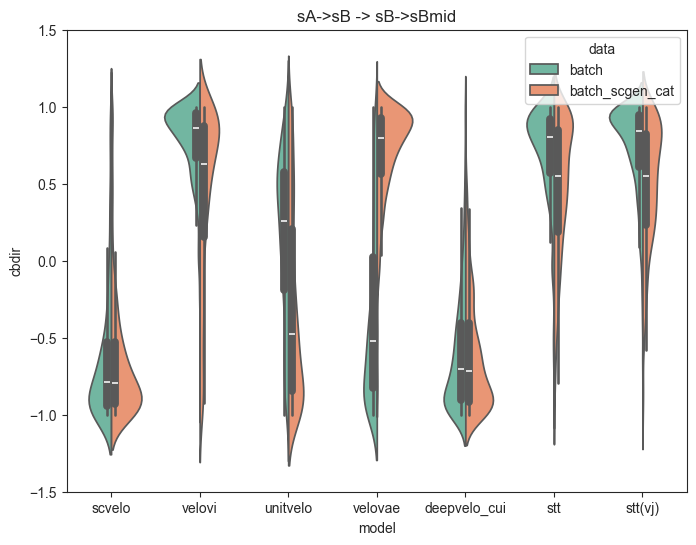

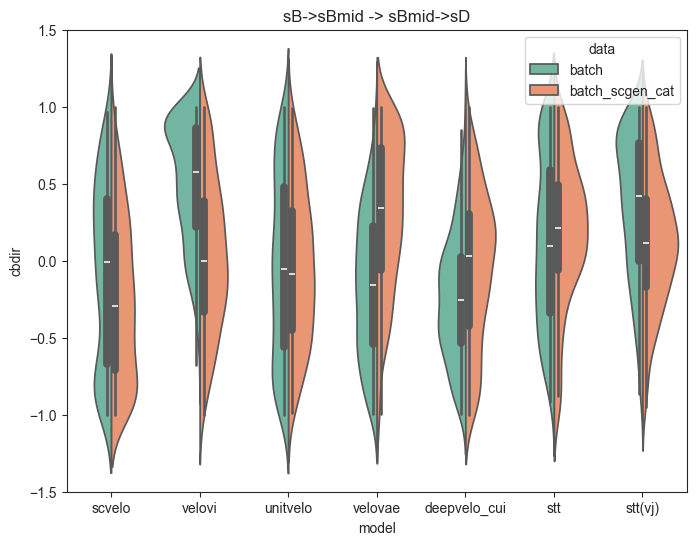

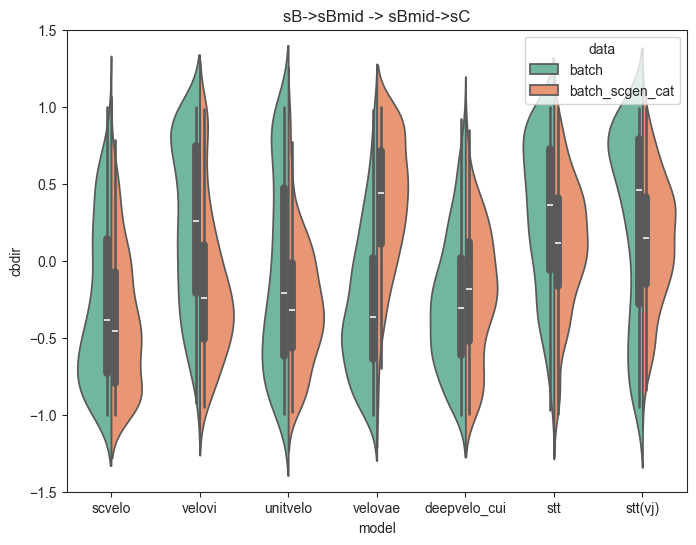

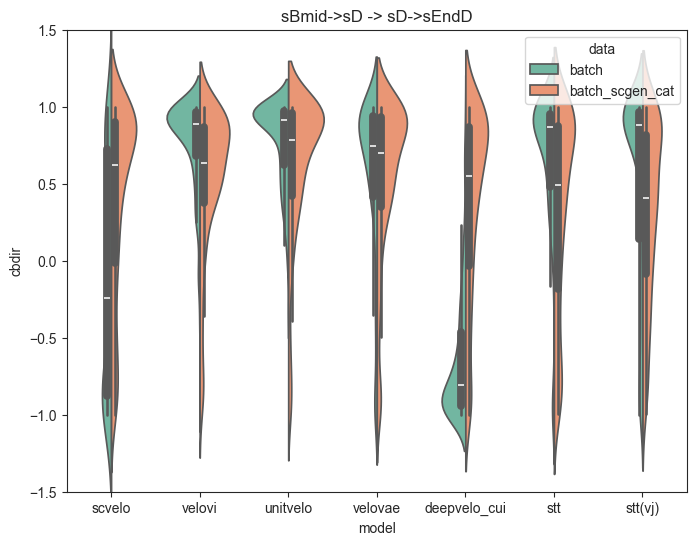

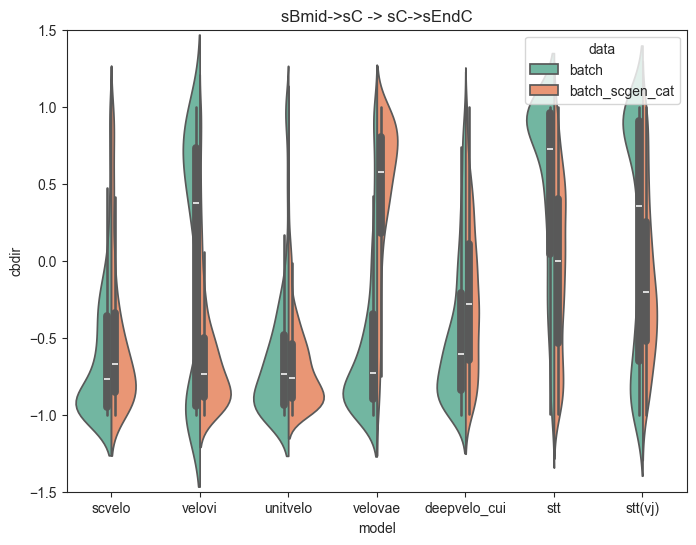

In [8]:
for key, value in results.items():
    df_list = []
    for model, metrics in value.items():
        for data, metric in metrics.items():
            df_list.append(pd.DataFrame({
                'model': [model] * len(metric),
                'data': [data.replace('simulate/', '')] * len(metric),
                metric_name: metric
            }))
    df = pd.concat(df_list)
    plt.figure(figsize=(8, 6))
    sns.violinplot(x='model', y=metric_name, hue='data', data=df, split=True, palette='Set2')
    plt.ylim(-1.5, 1.5) # remember to change this
    plt.title(key)
    plt.savefig(f'{save_dir}/{metric_name}_{key.replace(" -> ", "_").replace(" ", "_").replace("/", "_")}.svg')
    plt.show()